<a href="https://colab.research.google.com/github/Sumit-codes79/rendor-demo/blob/main/FYP_code_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import pickle
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
print("numpy",np.__version__)
print("pandas",pd.__version__)
print("sklearn",sklearn.__version__)

numpy 2.0.2
pandas 2.2.2
sklearn 1.6.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/dataset/synthetic_medical_triage.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      18000 non-null  float64
 1   heart_rate               18000 non-null  float64
 2   systolic_blood_pressure  18000 non-null  float64
 3   oxygen_saturation        18000 non-null  float64
 4   body_temperature         18000 non-null  float64
 5   pain_level               18000 non-null  int64  
 6   chronic_disease_count    18000 non-null  int64  
 7   previous_er_visits       18000 non-null  int64  
 8   arrival_mode             18000 non-null  object 
 9   triage_level             18000 non-null  int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 1.4+ MB


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0


In [ ]:
#checking the null value
df.isnull().sum()#there are no null values in this dataset
df.shape
df.describe()

,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,triage_level
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,44.716244,83.292322,128.072739,96.085183,37.224236,3.402111,1.072611,1.265056,0.697722
std,19.101056,16.964405,18.813277,3.330830,0.914978,2.039249,1.312204,1.454887,0.898923
min,0.000000,33.400000,65.800000,79.500000,34.470000,1.000000,0.000000,0.000000,0.000000
25%,31.200000,71.500000,114.900000,94.300000,36.580000,2.000000,0.000000,0.000000,0.000000
50%,44.000000,81.600000,126.900000,96.600000,37.120000,3.000000,1.000000,1.000000,0.000000
75%,57.500000,93.200000,139.900000,98.700000,37.770000,5.000000,2.000000,2.000000,1.000000
max,95.000000,152.300000,219.700000,100.000000,41.130000,10.000000,10.000000,11.000000,3.000000


In [ ]:
df.columns

Index(['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation',
       'body_temperature', 'pain_level', 'chronic_disease_count',
       'previous_er_visits', 'arrival_mode', 'triage_level'],
      dtype='object')

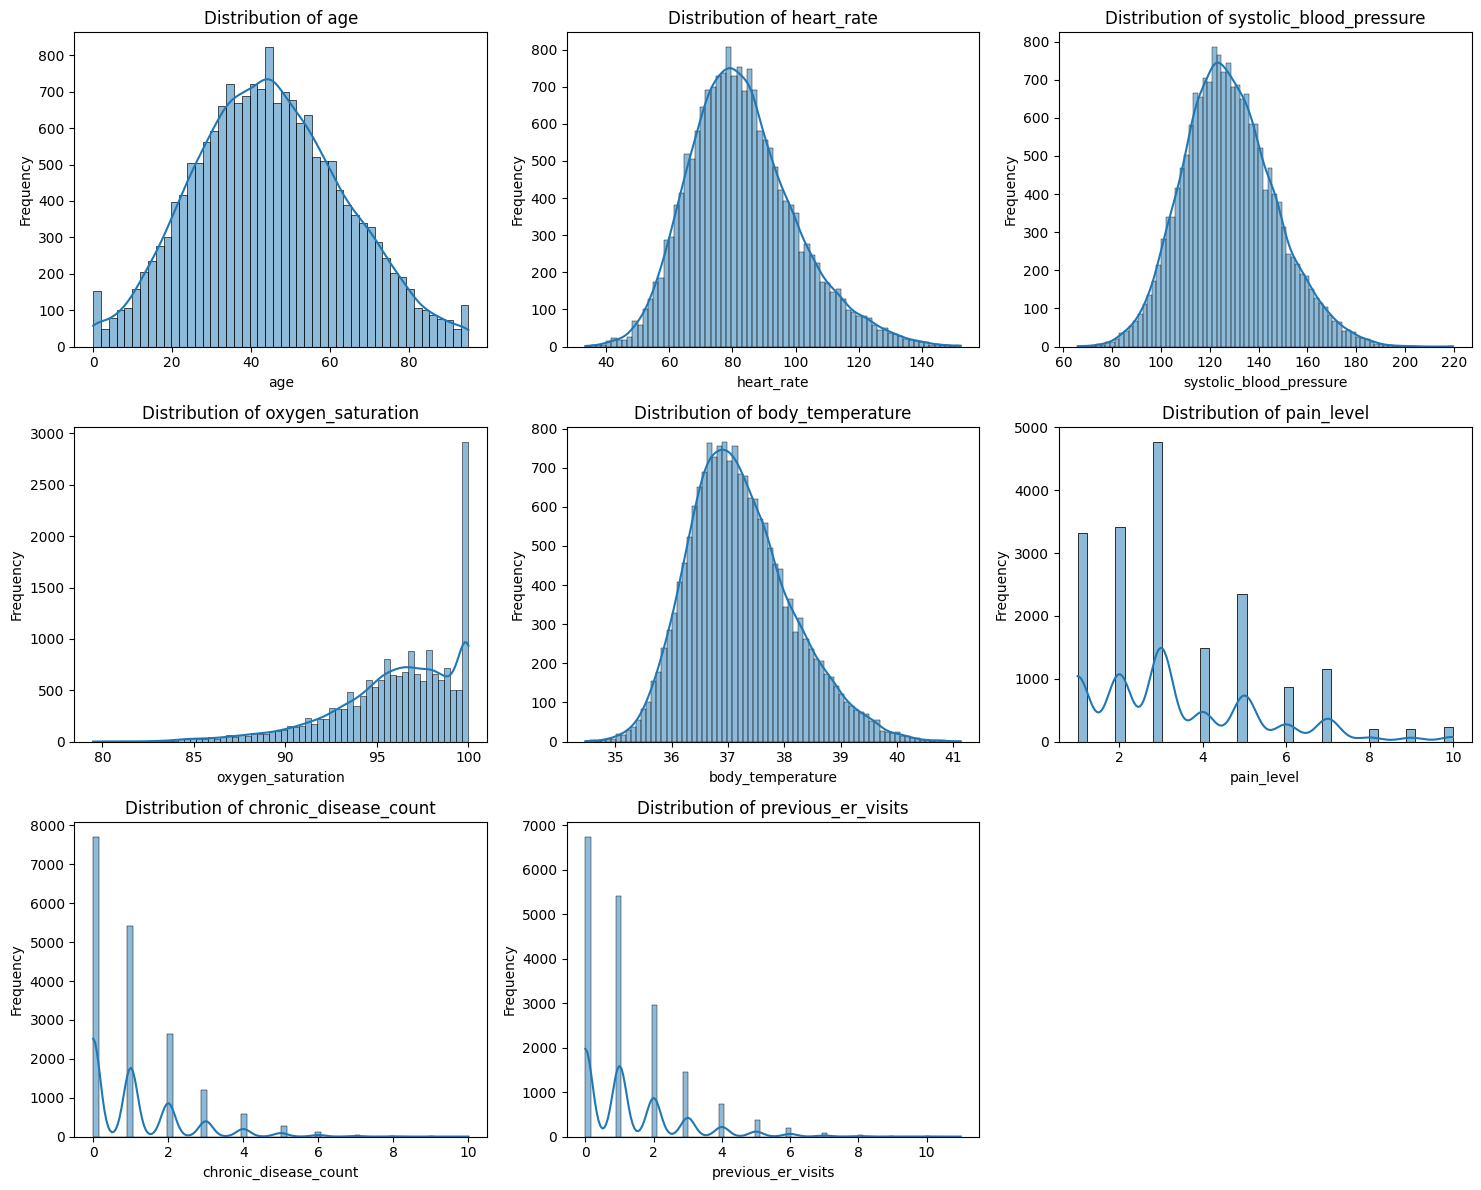

In [ ]:
#EDA (Exploratory Data Analysis)

import matplotlib.pyplot as plt
import seaborn as sns
import math

input_columns = [col for col in df.columns if col != 'triage_level' and df[col].dtype != 'object']

# Calculate number of rows and columns for the subplot grid
num_plots = len(input_columns)
n_cols = 3 # You can adjust this for desired number of columns
n_rows = math.ceil(num_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(input_columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

For categorical input columns, a bar plot is more appropriate to visualize their distribution. Let's create bar plots for them.

/tmp/ipykernel_399/3845298032.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis', ax=axes[i])


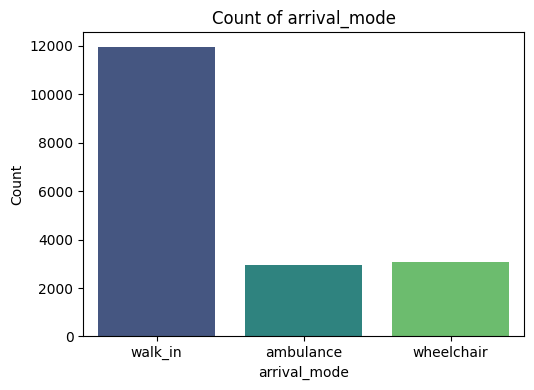

In [ ]:
#EDA for categorical data
import matplotlib.pyplot as plt
import seaborn as sns
import math

categorical_input_columns = [col for col in df.columns if df[col].dtype == 'object']

# Calculate number of rows and columns for the subplot grid
num_plots = len(categorical_input_columns)
n_cols = 2 # Adjust as needed
n_rows = math.ceil(num_plots / n_cols)

fig, ax_objects = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
# Ensure 'axes' is always a flat array of Axes objects
axes = ax_objects.flatten() if isinstance(ax_objects, np.ndarray) else np.array([ax_objects])

for i, col in enumerate(categorical_input_columns):
    sns.countplot(data=df, x=col, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

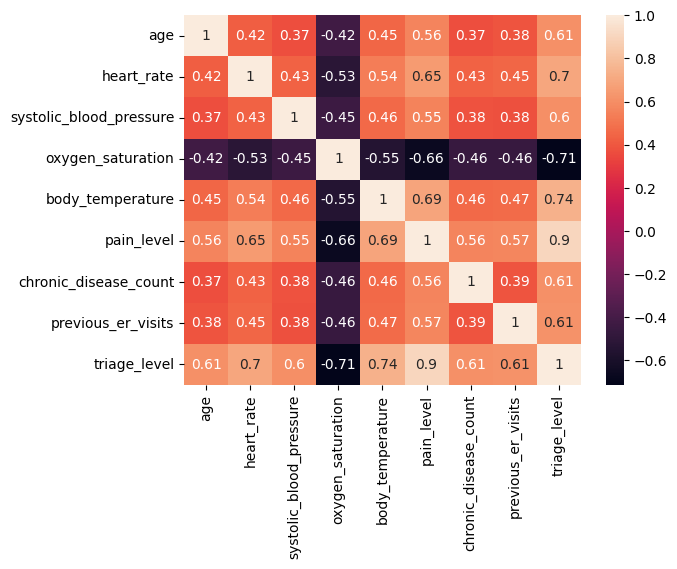

In [ ]:
#feature correlation (which feature most effect the triage level)
# Exclude non-numeric columns for correlation calculation(Heatmap)
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True)
plt.show()

In [ ]:
#train test split
x=df.drop('triage_level',axis=1)
y=df['triage_level']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.head()
x_test.head()
y_train.head()
y_test.head()
print(len(x_test))
print(len(x_train))

3600
14400


In [ ]:
x_train.head()

,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode
1921,59.7,63.2,118.5,96.6,37.23,2,1,0,walk_in
5732,30.5,76.6,134.5,98.5,37.34,5,2,0,walk_in
2455,30.1,67.5,143.3,98.7,36.65,3,0,0,walk_in
12131,43.2,68.5,136.7,99.0,35.69,3,0,0,ambulance
16612,28.0,93.5,111.5,99.6,37.37,2,0,0,walk_in


In [ ]:
y_train.head()

,triage_level
1921,0
5732,1
2455,0
12131,0
16612,0


In [ ]:
#ONE HOT ENCODING AND SCALLING
#1. One Hot Encoding for the column "Arrival Modee"
categorical_features = ['arrival_mode']
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 2. MinMax Scaling for numerical columns
# Identify numerical columns (excluding the categorical column and target if present)
numerical_features = ['age','heart_rate','systolic_blood_pressure','oxygen_saturation','body_temperature','pain_level','chronic_disease_count','previous_er_visits']  # Specify your numerical columns

# Create ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', MinMaxScaler(), numerical_features)
    ] # Keep other columns as-is
)
print("Our data is successfully One Hot Encoded and Min Max Scalled")


Our data is successfully One Hot Encoded and Min Max Scalled


In [ ]:
trf3=RandomForestClassifier()

In [ ]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', trf3)
])

In [ ]:
pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['arrival_mode']),
                                                 ('num', MinMaxScaler(),
                                                  ['age', 'heart_rate',
                                                   'systolic_blood_pressure',
                                                   'oxygen_saturation',
                                                   'body_temperature',
                                                   'pain_level',
                                                   'chronic_disease_count',
                                                   'previous_er_visits'])])),
                ('classifier', RandomForestClassifier())])

In [ ]:
pipe.named_steps

{'preprocessor': ColumnTransformer(transformers=[('cat',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  ['arrival_mode']),
                                 ('num', MinMaxScaler(),
                                  ['age', 'heart_rate',
                                   'systolic_blood_pressure',
                                   'oxygen_saturation', 'body_temperature',
                                   'pain_level', 'chronic_disease_count',
                                   'previous_er_visits'])]),
 'classifier': RandomForestClassifier()}

In [ ]:
y_pred = pipe.predict(x_test)

In [ ]:
y_pred

array([0, 0, 2, ..., 0, 1, 1])

In [ ]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print(f"Rendom Forest Accuracy: {acc}")

Rendom Forest Accuracy: 0.9430555555555555


In [ ]:
from sklearn import set_config
set_config(display='diagram')

In [ ]:
#cross validation for advanced accuracy [ K-Fold Cross Validation ]
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, x_train, y_train, cv=10,scoring='accuracy')

print("Accuracies:", scores)
print("Mean Accuracy:", scores.mean())

Accuracies: [0.93263889 0.93958333 0.94166667 0.93125    0.94513889 0.94305556
 0.9375     0.94583333 0.94444444 0.93541667]
Mean Accuracy: 0.9396527777777777


In [ ]:

#Detail Evolution
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1970   50    0    0]
 [  74  779   20    0]
 [   1   37  491    5]
 [   0    0   18  155]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      2020
           1       0.90      0.89      0.90       873
           2       0.93      0.92      0.92       534
           3       0.97      0.90      0.93       173

    accuracy                           0.94      3600
   macro avg       0.94      0.92      0.93      3600
weighted avg       0.94      0.94      0.94      3600



In [ ]:
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))